# Import Libraries

In [45]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load Dataset

In [ ]:
# df = pd.read_csv(r"D:\ClimateGuardAI\datasets\engineered\climate_anomaly_engineered.csv")
# # View data
# df.head()

,latitude,longitude,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,...,day_period_Morning,day_period_Night,season_Monsoon,season_Post_Monsoon,season_Summer,season_Winter,Cluster,Climate_Profile,Anomaly,Status
0,24.57,77.72,27.5,20.5,281,1008,0.0,67,26,29.7,...,1.0,0.0,1.0,0.0,0.0,0.0,6,NaN,1,Normal
1,23.33,77.80,27.5,15.5,287,1008,0.0,70,19,30.0,...,1.0,0.0,1.0,0.0,0.0,0.0,6,NaN,1,Normal
2,22.07,78.93,26.3,18.4,317,1009,0.0,70,51,28.2,...,1.0,0.0,1.0,0.0,0.0,0.0,6,NaN,-1,Anomaly
3,21.86,77.93,25.6,16.9,297,1009,0.0,76,65,27.6,...,1.0,0.0,1.0,0.0,0.0,0.0,6,NaN,-1,Anomaly
4,22.75,77.72,27.2,16.2,274,1009,0.0,74,82,29.9,...,1.0,0.0,1.0,0.0,0.0,0.0,6,NaN,1,Normal


# Create Target Variable: rainfall_risk

In [47]:
def rainfall_category(x):
    if x == 0:
        return "Low"
    elif x <= 10:
        return "Medium"
    else:
        return "High"

# df["rainfall_risk"] = df["precip_mm"].apply(rainfall_category)


new_col = pd.DataFrame({
    "rainfall_risk": df["precip_mm"].apply(rainfall_category)
})

df = pd.concat([df, new_col], axis=1).copy()
print(df["rainfall_risk"].value_counts())


rainfall_risk
Low       104510
Medium     14829
High          59
Name: count, dtype: int64


# Select Features

In [ ]:
features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'visibility_km',
    'uv_index',
    'wind_kph'
]

# Keep only existing columns

In [49]:
features = [col for col in features if col in df.columns]

X = df[features]
y = df["rainfall_risk"]

# Train-Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Model Training

## MODEL 1 : Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'newton-cg', 'saga']
}

lr_search = RandomizedSearchCV(
    lr,
    lr_params,
    cv=3,
    scoring='accuracy',
    n_iter=5
)

lr_search.fit(X_train_scaled, y_train)

lr_best = lr_search.best_estimator_

## MODEL 2 : Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=5,          # Reduced from 10
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

print("Best RF Params:", rf_search.best_params_)
print("Best CV Score:", rf_search.best_score_)



Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score: 0.9312066699510936


## MODEL 3 : XGBoost

In [51]:
# from xgboost import XGBClassifier
# from xgboost import XGBClassifier

# model = XGBClassifier(
#     eval_metric='mlogloss'
# )
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode target labels for XGBoost
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# xgb = XGBClassifier(
#     objective='multi:softmax',
#     num_class=len(np.unique(y_train_encoded)),
#     random_state=42,
#     use_label_encoder=False
# )
# from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train_encoded)

xgb_best = xgb_search.best_estimator_
print("Best XGB Params:", xgb_search.best_params_)



Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# Compare Models

In [52]:
# Make predictions on the test set for each model
lr_pred = lr_best.predict(X_test_scaled)
rf_pred = rf_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

# Calculate accuracy scores
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test_encoded, xgb_pred) # Use y_test_encoded for XGBoost accuracy

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        lr_acc,
        rf_acc,
        xgb_acc
    ]
})

print("\nModel Comparison")
print(results)


Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.881407
1        Random Forest  0.935050
2              XGBoost  0.920980


# Select Best Model

In [53]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("\nBest Model:")
print(best_model)


Best Model:
Model       Random Forest
Accuracy          0.93505
Name: 1, dtype: object


# Classification Report

In [54]:
if best_model['Model'] == 'Logistic Regression':
    final_pred = lr_pred

elif best_model['Model'] == 'Random Forest':
    final_pred = rf_pred

else:
    final_pred = xgb_pred

print("\nClassification Report")
print(classification_report(
    y_test,
    final_pred,
    target_names=encoder.classes_
))


Classification Report
              precision    recall  f1-score   support

        High       1.00      0.33      0.50        12
         Low       0.94      0.98      0.96     20902
      Medium       0.84      0.59      0.69      2966

    accuracy                           0.94     23880
   macro avg       0.93      0.64      0.72     23880
weighted avg       0.93      0.94      0.93     23880




📊 Classification Report
              precision    recall  f1-score   support

        High       1.00      0.33      0.50        12
         Low       0.94      0.98      0.96     20902
      Medium       0.84      0.59      0.69      2966

    accuracy                           0.94     23880
   macro avg       0.93      0.64      0.72     23880
weighted avg       0.93      0.94      0.93     23880


🔥 Confusion Matrix:
 [[    4     2     6]
 [    0 20562   340]
 [    0  1203  1763]]


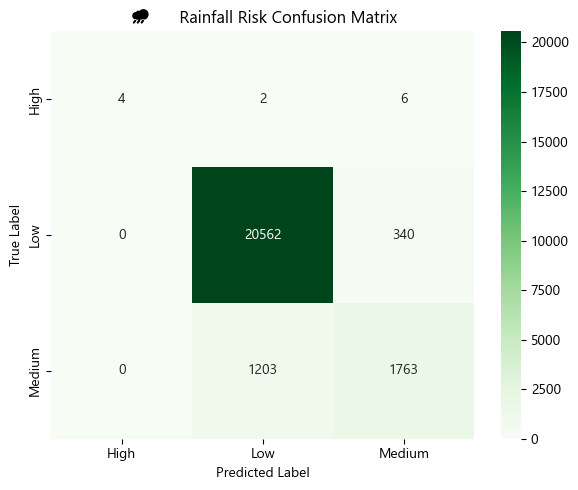

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

plt.rcParams['font.family'] = 'Segoe UI Emoji'
# =========================
# MODEL SELECTION LOGIC
# =========================
if best_model['Model'] == 'Logistic Regression':
    final_pred = lr_pred

elif best_model['Model'] == 'Random Forest':
    final_pred = rf_pred

else:
    final_pred = xgb_pred

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n📊 Classification Report")
print(classification_report(
    y_test,
    final_pred,
    target_names=encoder.classes_
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, final_pred)
print("\n🔥 Confusion Matrix:\n", cm)

# =========================
# PLOT CONFUSION MATRIX
# =========================
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("🌧️ Rainfall Risk Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# Predict Rainfall Risk for New Data

In [ ]:
sample = pd.DataFrame({
    'temperature_celsius': [30],
    'humidity': [85],
    'pressure_mb': [1005],
    'air_quality_PM2.5': [40],
    'air_quality_PM10': [60],
    'visibility_km': [6],
    'uv_index': [7],
    'wind_kph': [15]
})

sample = sample[features]

# Scale the sample data for Logistic Regression
sample_scaled = scaler.transform(sample)

if best_model['Model'] == 'Logistic Regression':
    prediction_raw = lr_best.predict(sample_scaled)
    risk = prediction_raw[0]

elif best_model['Model'] == 'Random Forest':
    prediction_raw = rf_best.predict(sample)
    risk = prediction_raw[0]

else: # XGBoost
    prediction_encoded = xgb_best.predict(sample)
    risk = encoder.inverse_transform(prediction_encoded)[0]

print("\nPredicted Rainfall Risk:")
print(risk)


Predicted Rainfall Risk:
Low


# SAVE ENGINEERED DATASET

In [57]:
import os
import pickle

# Save dataset with rainfall risk column
output_dir = r"D:\ClimateGuardAI\datasets\engineered"

os.makedirs(output_dir, exist_ok=True)

output_path = f"{output_dir}/rainfall_risk_engineered.csv"

df.to_csv(output_path, index=False)

print(f"\nRainfall risk dataset saved successfully at:\n{output_path}")


Rainfall risk dataset saved successfully at:
D:\ClimateGuardAI\datasets\engineered/rainfall_risk_engineered.csv


# SAVE MODELS (.pkl FILES)

In [58]:

save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)


# Save Label Encoder
with open(os.path.join(save_path,
                       'rainfall_risk_label_encoder.pkl'), 'wb') as file:
    pickle.dump(encoder, file)


# Save Scaler (used for Logistic Regression)
with open(os.path.join(save_path,
                       'rainfall_risk_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)


# Save Best Model
if best_model['Model'] == 'Logistic Regression':

    with open(os.path.join(save_path,
                           'rainfall_risk_logistic_regression.pkl'),
              'wb') as file:
        pickle.dump(lr, file)

    print("Saved: rainfall_risk_logistic_regression.pkl")


elif best_model['Model'] == 'Random Forest':

    with open(os.path.join(save_path,
                           'rainfall_risk_random_forest.pkl'),
              'wb') as file:
        pickle.dump(rf, file)

    print("Saved: rainfall_risk_random_forest.pkl")


else:

    with open(os.path.join(save_path,
                           'rainfall_risk_xgboost.pkl'),
              'wb') as file:
        pickle.dump(xgb, file)

    print("Saved: rainfall_risk_xgboost.pkl")


print("\nAll rainfall risk artifacts saved successfully.")
print("Files saved in:", save_path)

# Possible Outputs:
# Low
# Medium
# High


Saved: rainfall_risk_random_forest.pkl

All rainfall risk artifacts saved successfully.
Files saved in: D:\ClimateGuardAI\backend\ml\artifacts


# Distribution of Rainfall Risk Categories

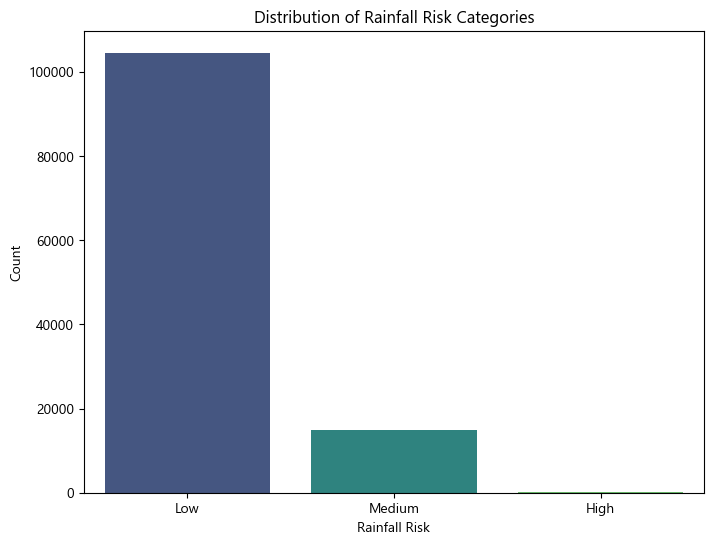

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class imbalance
plt.figure(figsize=(8, 6))
sns.countplot(
    x='rainfall_risk',
    data=df,
    order=df['rainfall_risk'].value_counts().index,
    hue='rainfall_risk',
    palette='viridis',
    legend=False
)
plt.title('Distribution of Rainfall Risk Categories')
plt.xlabel('Rainfall Risk')
plt.ylabel('Count')
plt.show()